# Social Media impact on Students mental health EDA

## importing necessary libraries

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## loading the dataset

In [234]:
df = pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')

In [173]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## Inspecting the dataset

In [235]:
df.shape

(5000, 13)

In [236]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [177]:
df.isna().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


### Initial Data Inspection

The dataset contains records for **5,000 students** and consists of **13 features**. The available features are:

* Age
* Gender
* Country
* Academic_Level
* Most_Used_Platform
* Purpose_Of_Use
* Avg_Daily_Usage_Hours
* Daily_Unlocks
* Study_Hours
* Physical_Activity_Hours
* Sleep_Hours_Per_Night
* Stress_Level
* Mental_Health_Score

An initial inspection of the dataset shows that all **5,000 records are complete**, with **no missing (null) values** present in any of the features. This indicates that the dataset is clean and does not require missing value imputation before performing exploratory data analysis (EDA) or building machine learning models.


## Univariate Analysis
- Gender : There are 52.7% Males and 47.3% females in the dataset
- Country : The country column shows that the dataset has students from 111 countries
- Academic level This dataset has three types of Academic level Undergraduate , graduate , high school

In [238]:
df2 = df.copy()
sns.set_palette('muted')
sns.set_style('darkgrid')

In [179]:
Gender_count = df2['Gender'].value_counts()
Gender_count

,count
Gender,
Male,2635
Female,2365


Gender Distribution

The dataset consists of 52.7% male students and 47.3% female students. Male students form the slightly larger group, with a difference of approximately 5.4 percentage points compared to female students.

Overall, the gender distribution is relatively balanced, with only a slight imbalance in favor of male students.

([<matplotlib.patches.Wedge at 0x7f085419e1e0>,
 [Text(-0.09319351399917283, 1.0960451491377927, 'Male'),
  Text(0.09319360981848643, -1.0960451409905525, 'Female')],
 [Text(-0.05083282581773063, 0.5978428086206141, '52.7%'),
  Text(0.05083287808281077, -0.5978428041766649, '47.3%')])

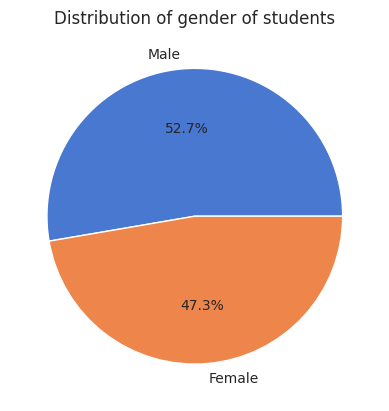

In [180]:
plt.title('Distribution of gender of students')
plt.pie(Gender_count,autopct='%1.1f%%',labels=Gender_count.index)

In [239]:
df2['Country'].unique().size

111

In [182]:
df2['Country'].value_counts()/len(df2)*100

,count
Country,
Other,37.60
India,7.78
USA,7.10
Canada,4.60
Australia,3.96
...,...
Armenia,0.02
Bosnia,0.02
Kuwait,0.02


In [183]:
top_ten_countries=df2['Country'].value_counts()[:10]
top_ten_countries

,count
Country,
Other,1880
India,389
USA,355
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


Text(0, 0.5, 'Country')

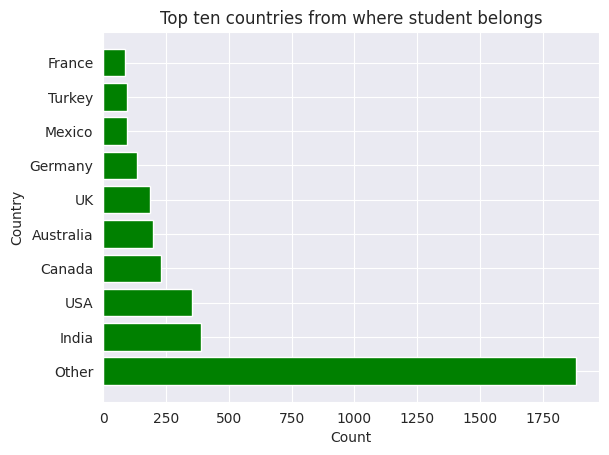

In [184]:
plt.title('Top ten countries from where student belongs')
plt.barh(y=top_ten_countries.index,width=top_ten_countries.values,color='green')
plt.xlabel('Count')
plt.ylabel('Country')

### Distribution of Students by Country

The dataset contains students from **111 different countries**, demonstrating a broad geographical representation. The **top ten countries** by student count are shown below:

| Country   | Number of Students |
| --------- | -----------------: |
| Other     |              1,880 |
| India     |                389 |
| USA       |                355 |
| Canada    |                230 |
| Australia |                198 |
| UK        |                185 |
| Germany   |                136 |
| Mexico    |                 94 |
| Turkey    |                 94 |
| France    |                 87 |

The **'Other'** category is the largest, accounting for **1,880 students (37.6%)**, followed by **India (389 students)** and the **USA (355 students)**. While these countries contribute a significant portion of the dataset, the remaining records are distributed across **111 countries**, with several countries represented by only a few students and some by **just a single student**.

This distribution indicates that the dataset has extensive global coverage but is highly imbalanced across countries. The presence of many countries with very few observations suggests that analyses involving the **Country** feature should be interpreted carefully, as results for sparsely represented countries may not be statistically reliable.


In [240]:
df2['Academic_Level'].unique()

array(['Undergraduate', 'Graduate', 'High School'], dtype=object)

In [241]:
academic_level_count = df2['Academic_Level'].value_counts()

Text(0.5, 1.0, 'Academic level distribution')

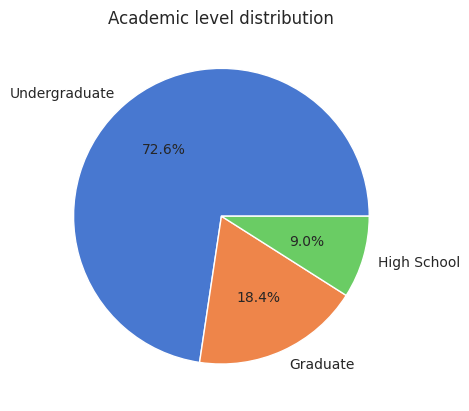

In [187]:
plt.pie(academic_level_count,labels=academic_level_count.index,autopct='%1.1f%%')
plt.title('Academic level distribution')

### Academic Level Distribution

The dataset includes students from **three academic levels**: **Undergraduate**, **Graduate**, and **High School**.

Among these groups, **Undergraduate** students constitute the largest proportion of the dataset, accounting for **72.6%** of all records. This is followed by **Graduate** students, who represent **18.4%**, while **High School** students make up the remaining **9.0%**.

The distribution is noticeably imbalanced, with undergraduate students comprising nearly three-quarters of the dataset. Consequently, analyses performed on the dataset are likely to be influenced primarily by undergraduate students, whereas insights related to graduate and high school students should be interpreted with caution due to their comparatively smaller representation.


In [242]:
df2['Most_Used_Platform'].unique()

array(['Facebook', 'LinkedIn', 'Instagram', 'Snapchat', 'Twitter',
       'YouTube', 'TikTok', 'LINE', 'KakaoTalk', 'VKontakte', 'WhatsApp',
       'WeChat'], dtype=object)

In [243]:
most_used_platform_count = df2['Most_Used_Platform'].value_counts()

In [244]:
most_used_platform_count

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


([<matplotlib.patches.Wedge at 0x7f08538a2420>,
 [Text(0.8341981217126275, 0.7170170805016602, 'Instagram'),
  Text(-0.45455469899991424, 1.0016885871452752, 'TikTok'),
  Text(-1.0925770378933626, 0.1275751396948712, 'Facebook'),
  Text(-0.8661966811567459, -0.6780142399338225, 'LinkedIn'),
  Text(-0.2929257920914337, -1.060280378167778, 'YouTube'),
  Text(0.3556551956309439, -1.0409175672553113, 'Twitter'),
  Text(0.8502021057446216, -0.6979658869797373, 'Snapchat'),
  Text(1.0463757681562063, -0.3392605957306411, 'WhatsApp'),
  Text(1.0837389222168934, -0.188440835468766, 'LINE'),
  Text(1.0926570710383898, -0.1268878446101417, 'VKontakte'),
  Text(1.0974683788760013, -0.07458657632095765, 'KakaoTalk'),
  Text(1.099718619652334, -0.024878858293042014, 'WeChat')],
 [Text(0.4550171572977968, 0.3911002257281783, '22.6%'),
  Text(-0.2479389267272259, 0.5463755929883319, '18.4%'),
  Text(-0.5959511115781977, 0.06958643983356609, '14.4%'),
  Text(-0.47247091699458854, -0.3698259490548122, 

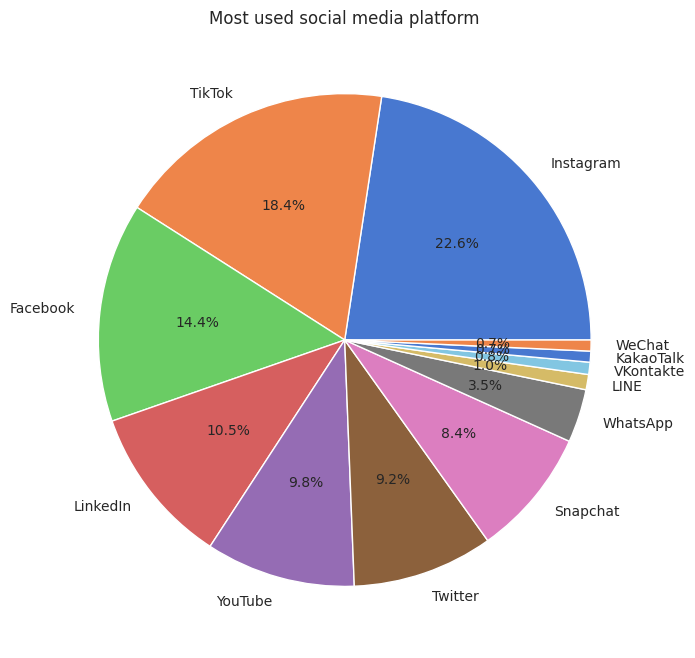

In [191]:
plt.figure(figsize=(14,8))
plt.title("Most used social media platform")
plt.pie(most_used_platform_count,labels=most_used_platform_count.index,autopct='%1.1f%%')

### Distribution of Most Used Social Media Platform

The dataset includes students who primarily use a variety of social media platforms. **Instagram** is the most commonly used platform, accounting for **22.6%** of the students. It is followed by **TikTok (18.4%)** and **Facebook (14.4%)**, making these the three most popular platforms among the respondents.

The remaining platform distribution is as follows:

| Social Media Platform | Number of Students |
| --------------------- | -----------------: |
| Instagram             |      1,130 (22.6%) |
| TikTok                |        920 (18.4%) |
| Facebook              |        720 (14.4%) |
| LinkedIn              |        523 (10.5%) |
| YouTube               |         491 (9.8%) |
| Twitter               |         462 (9.2%) |
| Snapchat              |         420 (8.4%) |
| WhatsApp              |         175 (3.5%) |
| LINE                  |          50 (1.0%) |
| VKontakte             |          40 (0.8%) |
| KakaoTalk             |          36 (0.7%) |
| WeChat                |          36 (0.7%) |

The distribution indicates that **Instagram, TikTok, and Facebook** collectively account for more than half of the students' primary social media platform preferences. In contrast, platforms such as **LINE, VKontakte, KakaoTalk, and WeChat** have relatively few users, each representing less than **1%** of the dataset. This suggests that students in the dataset predominantly prefer mainstream social media platforms, while regional or niche platforms have comparatively lower adoption.


In [245]:
df2['Purpose_Of_Use'].unique()

array(['Networking', 'Education', 'Entertainment', 'News'], dtype=object)

In [193]:
Purpose_Of_Use=df2['Purpose_Of_Use'].value_counts()
Purpose_Of_Use

,count
Purpose_Of_Use,
Entertainment,2552
Education,1094
Networking,793
News,561


([<matplotlib.patches.Wedge at 0x7f0853989130>,
 [Text(-0.03593343104708764, 1.0994129290367585, 'Entertainment'),
  Text(-0.8028112192748954, -0.7519934482469618, 'Education'),
  Text(0.39528019941894704, -1.026524994312032, 'Networking'),
  Text(1.0323689383172698, -0.37975567829549756, 'News')],
 [Text(-0.01960005329841144, 0.5996797794745954, '51.0%'),
  Text(-0.43789702869539743, -0.4101782444983427, '21.9%'),
  Text(0.2156073815012438, -0.5599227241701993, '15.9%'),
  Text(0.563110329991238, -0.2071394608884532, '11.2%')])

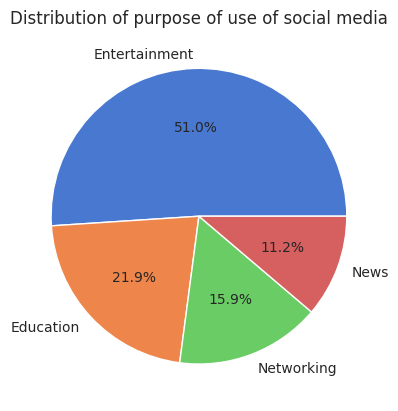

In [194]:
plt.title('Distribution of purpose of use of social media')
plt.pie(Purpose_Of_Use,autopct='%1.1f%%',labels=Purpose_Of_Use.index)

### Purpose of Social Media Use

The distribution of the **Purpose of Social Media Use** indicates that **Entertainment** is the primary reason students use social media. Approximately **51.0%** of the students reported using social media mainly for entertainment, accounting for more than half of the dataset.

The second most common purpose is **Education**, with around **20.0%** of students using social media as a learning resource. This is followed by **Networking**, which accounts for **15.9%** of the respondents, while **11.2%** primarily use social media to stay updated with **News**.

These findings suggest that social media is predominantly viewed as a source of entertainment among students, although a substantial proportion also utilize these platforms for educational purposes and professional or social networking. Comparatively, using social media primarily for news consumption is the least common purpose among the four categories.


In [246]:
df2['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [196]:
stress_level = df2['Stress_Level'].value_counts()
stress_level

,count
Stress_Level,
Very High,1621
High,1440
Medium,1295
Low,644


([<matplotlib.patches.Wedge at 0x7f085394a660>,
 [Text(0.5771037736407029, 0.9364567445694759, 'Very High'),
  Text(-1.0781158441390604, 0.21832596413693367, 'High'),
  Text(-0.057338738826991274, -1.0985045603135792, 'Medium'),
  Text(1.0111700383507989, -0.43305329180326546, 'Low')],
 [Text(0.3147838765312925, 0.5107945879469868, '32.4%'),
  Text(-0.5880631877122147, 0.11908688952923653, '28.8%'),
  Text(-0.031275675723813415, -0.5991843056255887, '25.9%'),
  Text(0.5515472936458903, -0.23621088643814478, '12.9%')])

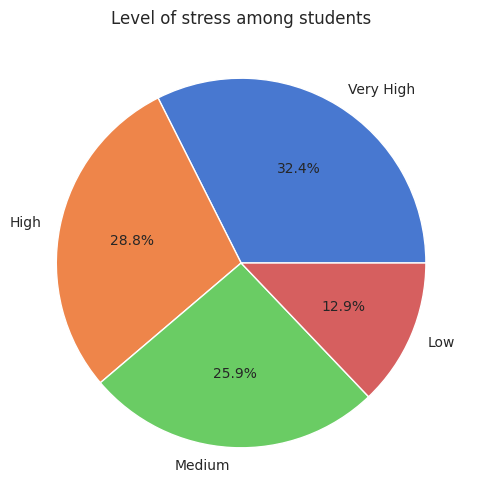

In [197]:
plt.figure(figsize=(12,6))
plt.title('Level of stress among students')
plt.pie(stress_level,autopct='%1.1f%%',labels=stress_level.index)

### Distribution of Stress Level

The self-reported stress levels indicate that a considerable proportion of students experience elevated levels of stress. Approximately **32.4%** of the students reported having a **Very High** stress level, making it the largest category. This is followed by **High** stress at **28.8%**, **Medium** stress at **25.9%**, and **Low** stress at **12.9%**.

Overall, **61.2%** of the students reported experiencing either **High** or **Very High** stress levels, suggesting that a majority of the participants face significant levels of stress. In contrast, only **12.9%** reported a **Low** stress level. This distribution highlights that stress is a prevalent concern among the students in the dataset and may have a substantial impact on their overall well-being and mental health.


## Univariate Analysis on numerical columns
- Age : Students ranging from age 18-24 we have

In [198]:
df2['Age'].describe()

,Age
count,5000.00000
mean,20.82180
std,1.73662
min,18.00000
25%,19.00000
50%,21.00000
75%,22.00000
max,24.00000


In [199]:
df2['Age'].value_counts().sort_index()

,count
Age,
18,450
19,906
20,883
21,947
22,896
23,496
24,422


<Axes: title={'center': 'Distribution of Age'}, xlabel='Age', ylabel='Count'>

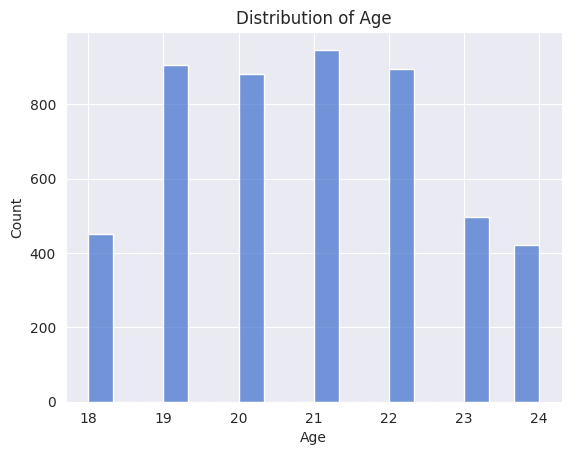

In [200]:
plt.title('Distribution of Age')
sns.histplot(df2['Age'])

### Age Distribution

The age distribution of the students indicates that the majority fall within the **19–22 years** age range, suggesting that the dataset is primarily composed of students in the typical age group for higher education.

Among all age groups, **24-year-old** students constitute the smallest group in the dataset. This uneven distribution reflects a greater concentration of younger students, while relatively fewer participants belong to the older age categories.


In [201]:
df['Physical_Activity_Hours'].describe()

,Physical_Activity_Hours
count,5000.000000
mean,1.751000
std,0.668398
min,-0.400000
25%,1.300000
50%,1.700000
75%,2.200000
max,4.100000


In [202]:
df2.loc[df2['Physical_Activity_Hours']<0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2277,20,Male,Other,Undergraduate,Facebook,Networking,6.8,222,2.6,-0.1,4.7,Very High,4.6
2923,23,Female,USA,Graduate,Snapchat,Entertainment,7.9,223,1.1,-0.1,5.8,Very High,5.2
3056,19,Male,Other,Undergraduate,LinkedIn,Education,7.8,252,1.6,-0.3,5.7,Very High,4.3
3422,24,Male,Other,Graduate,Twitter,News,8.2,245,0.7,-0.1,5.8,Very High,4.4
3882,20,Female,Other,Undergraduate,YouTube,Education,5.5,207,2.2,-0.2,5.1,Very High,5.7
4058,21,Male,Other,Undergraduate,YouTube,Education,5.8,200,2.0,-0.1,7.4,High,6.2
4243,20,Female,Other,Undergraduate,YouTube,Education,5.6,207,2.6,-0.4,5.0,Very High,5.4
4406,20,Male,Other,Undergraduate,Facebook,Networking,7.2,222,2.6,-0.3,4.5,Very High,4.5
4522,19,Male,Other,Undergraduate,LinkedIn,Education,8.1,252,2.2,-0.2,5.7,Very High,4.1
4771,21,Male,India,Undergraduate,TikTok,Entertainment,7.6,222,1.0,-0.2,5.2,Very High,4.5


### Handling Invalid Values in Physical Activity Hours
During the analysis of the Physical_Activity_Hours feature, it was observed that some records contained negative values. Since the number of hours spent on physical activity cannot be negative, these values were identified as invalid and required preprocessing before conducting further analysis.

Assuming that the negative sign resulted from a data entry error, the invalid values were converted to their corresponding positive (absolute) values. This transformation ensured that the feature contained only valid physical activity durations while preserving the original magnitude of the recorded values.


In [247]:
df2['Physical_Activity_Hours'] = df2['Physical_Activity_Hours'].map(abs)

In [204]:
df2['Physical_Activity_Hours'].describe()

,Physical_Activity_Hours
count,5000.000000
mean,1.751800
std,0.666298
min,0.000000
25%,1.300000
50%,1.700000
75%,2.200000
max,4.100000


<Axes: title={'center': 'Distribution of Physical Activity Hours'}, xlabel='Physical_Activity_Hours', ylabel='Count'>

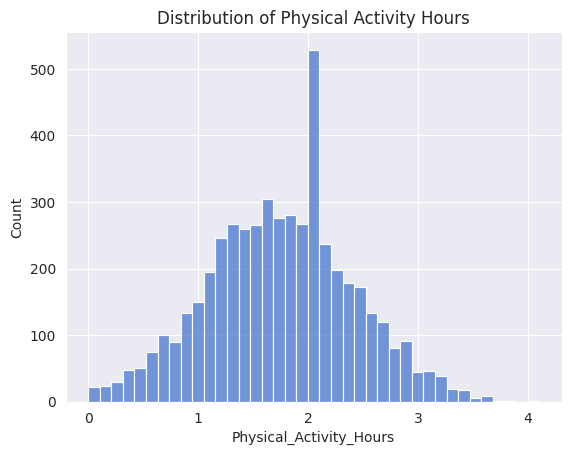

In [205]:
plt.title('Distribution of Physical Activity Hours')
sns.histplot(df2['Physical_Activity_Hours'])

### Distribution of Physical Activity Hours

The distribution of **Physical_Activity_Hours** shows that most students engage in **approximately 1.3 to 2.2 hours** of physical activity per day. A noticeable concentration of observations is present around **2.0 to 2.1 hours**, indicating that this is the most common duration of daily physical activity among the students.

The distribution is **unimodal** with a prominent peak near 2 hours and gradually tapers off on both sides. While most students report moderate levels of physical activity, a small proportion of students engage in **very little or no physical activity**, with values close to **0 hours**. Similarly, relatively few students report engaging in more than **3 hours** of physical activity per day.

Overall, the distribution suggests that the majority of students maintain a moderate level of daily physical activity, with **2 hours per day** being the most frequently reported duration.


In [206]:
df2['Study_Hours'].describe()

,Study_Hours
count,5000.000000
mean,3.008420
std,1.637018
min,0.300000
25%,1.500000
50%,2.800000
75%,4.200000
max,8.300000


<Axes: ylabel='Study_Hours'>

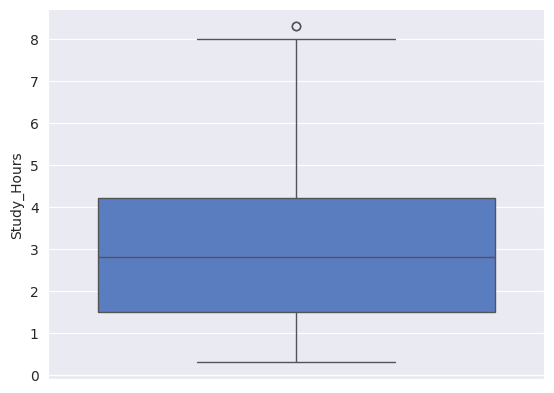

In [207]:
sns.boxplot(df2['Study_Hours'])

<Axes: title={'center': 'Distribution of time spent on studying'}, xlabel='Study_Hours', ylabel='Count'>

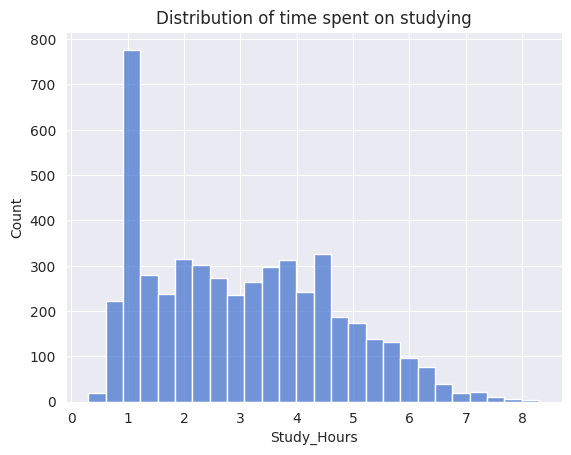

In [208]:
plt.title('Distribution of time spent on studying')
sns.histplot(df2['Study_Hours'])

### Distribution of Study Hours

The distribution of **Study_Hours** indicates that **approximately 1 hour per day** is the most frequently reported study duration among students, as evidenced by the prominent peak around the 1-hour mark.

Overall, most students study between **1 and 4 hours per day**, with the frequency of observations remaining relatively high within this range. Beyond **4.5 hours**, the number of students decreases steadily, indicating that comparatively few students dedicate more than 4.5 hours per day to studying.

The distribution is **positively (right) skewed**, with a long tail extending towards higher study durations of up to approximately **8 hours**. This suggests that while the majority of students engage in moderate daily study sessions, only a small proportion study for extended periods.

In [209]:
df2['Avg_Daily_Usage_Hours'].describe()

,Avg_Daily_Usage_Hours
count,5000.000000
mean,5.078460
std,1.653913
min,1.000000
25%,3.800000
50%,5.000000
75%,6.300000
max,8.800000


<Axes: title={'center': 'Distibution of the average time spent on Social media'}, xlabel='Avg_Daily_Usage_Hours', ylabel='Count'>

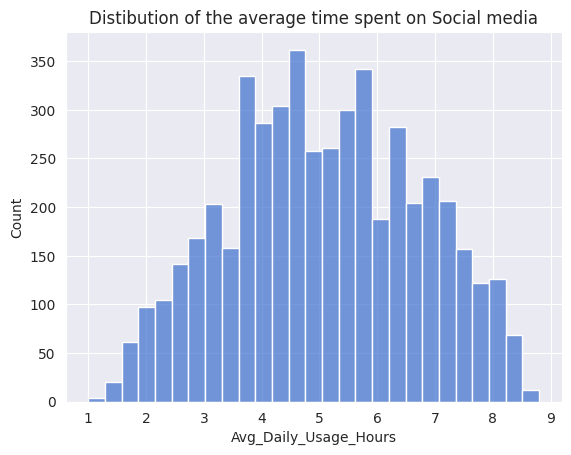

In [210]:
plt.title('Distibution of the average time spent on Social media')
sns.histplot(df2['Avg_Daily_Usage_Hours'])

### Distribution of Average Daily Social Media Usage Hours

The distribution of **Avg_Daily_Usage_Hours** indicates that the majority of students spend between **3.8 and 5.9 hours** per day on social media. This range represents the highest concentration of observations, suggesting that most students are moderate to heavy social media users.

The frequency of students decreases gradually for usage durations below **3.8 hours** and above **5.9 hours**. A relatively small number of students report using social media for **around 1 hour per day**, while only a few students spend **more than 8 hours daily** on social media.

Overall, the distribution is approximately **bell-shaped**, with the highest density centered around **5 hours of daily usage**. This suggests that spending **4–6 hours per day** on social media is the most common usage pattern among the students in the dataset, whereas very low and very high usage durations are comparatively uncommon.


In [211]:
df2['Daily_Unlocks'].describe()

,Daily_Unlocks
count,5000.000000
mean,171.452600
std,42.858254
min,62.000000
25%,140.000000
50%,171.000000
75%,204.000000
max,273.000000


<Axes: title={'center': 'Distribution of phone unlocks in a day'}, xlabel='Daily_Unlocks', ylabel='Count'>

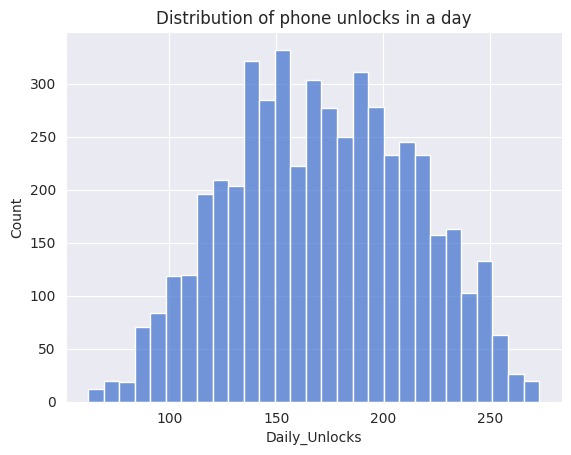

In [212]:
plt.title('Distribution of phone unlocks in a day')
sns.histplot(df2['Daily_Unlocks'])

### Distribution of Daily Phone Unlocks

The **Daily_Unlocks** feature indicates that students unlock their phones a **minimum of 62 times per day**, while the maximum number of daily unlocks reaches **273**.

Most students unlock their phones between **130 and 200 times per day**, indicating frequent interaction with their smartphones throughout the day. The number of students gradually decreases as the daily unlock count increases beyond **200**. Additionally, the upper quartile of the distribution shows that **25% of the students unlock their phones more than 204 times per day**, highlighting a substantial proportion of heavy smartphone users.

Overall, the distribution suggests that smartphone usage is very high among the students, with most individuals unlocking their devices well over **100 times per day** and a significant fraction exceeding **200 daily unlocks**.



In [213]:
df2['Sleep_Hours_Per_Night'].describe()

,Sleep_Hours_Per_Night
count,5000.000000
mean,6.634580
std,1.221391
min,3.600000
25%,5.600000
50%,6.600000
75%,7.500000
max,9.900000


<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Count'>

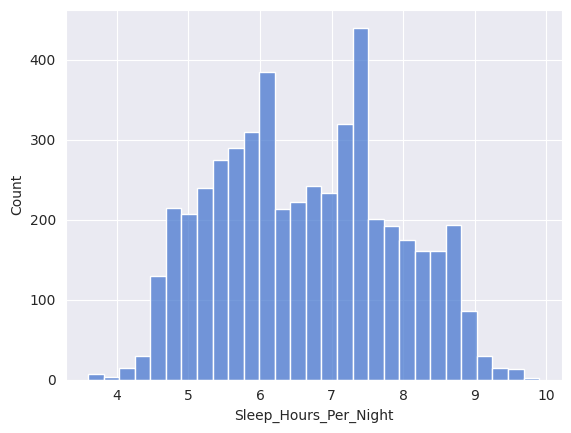

In [214]:
sns.histplot(df2['Sleep_Hours_Per_Night'])

Distribution of Sleep Hours per Night

The Sleep_Hours_Per_Night feature indicates that students sleep for a minimum of 3.6 hours and a maximum of 9.9 hours per night. Most students report sleeping between 5 and 8 hours per night, with a noticeable peak around 7.3–7.5 hours, indicating that this is the most common sleep duration among the respondents.

The frequency of observations gradually decreases for sleep durations below 5 hours and above 8 hours. A small proportion of students sleep less than 4 hours, while relatively few report sleeping more than 9 hours per night. Overall, the distribution suggests that the majority of students obtain a moderate to adequate amount of sleep, with approximately 7.5 hours being the most frequently reported duration.

In [215]:
df2['Mental_Health_Score'].describe()

,Mental_Health_Score
count,5000.000000
mean,6.230980
std,1.278701
min,3.600000
25%,5.100000
50%,6.100000
75%,7.100000
max,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Density'>

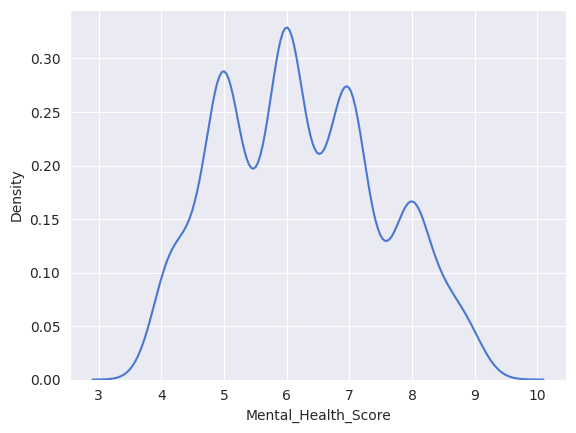

In [216]:
sns.kdeplot(df2['Mental_Health_Score'])

The KDE plot shows that most students have a Mental_Health_Score between 5 and 7, indicating that the majority fall within the moderate range of the distribution. A smaller proportion of students have lower scores around 3–4, while some students have higher scores approaching 9–10. Overall, the distribution suggests that mental health scores are concentrated in the middle range, with relatively fewer students at the lower and higher ends of the scale.

## Bivariate Analysis

In [217]:
platform_vs_purpose=pd.crosstab(df2['Most_Used_Platform'],df2['Purpose_Of_Use'],normalize='columns')
platform_vs_purpose

Purpose_Of_Use,Education,Entertainment,Networking,News
Most_Used_Platform,,,,
Facebook,0.000000,0.000000,0.906683,0.000000
Instagram,0.000000,0.442790,0.000000,0.000000
KakaoTalk,0.004570,0.004310,0.012610,0.017825
LINE,0.013711,0.005094,0.012610,0.021390
LinkedIn,0.478062,0.000000,0.000000,0.000000
Snapchat,0.000000,0.164577,0.000000,0.000000
TikTok,0.000000,0.359718,0.000000,0.000000
Twitter,0.000000,0.000000,0.000000,0.823529
VKontakte,0.005484,0.005486,0.011349,0.019608


<Axes: title={'center': 'Comparison of purpose of use vs platform'}, xlabel='Purpose_Of_Use', ylabel='Most_Used_Platform'>

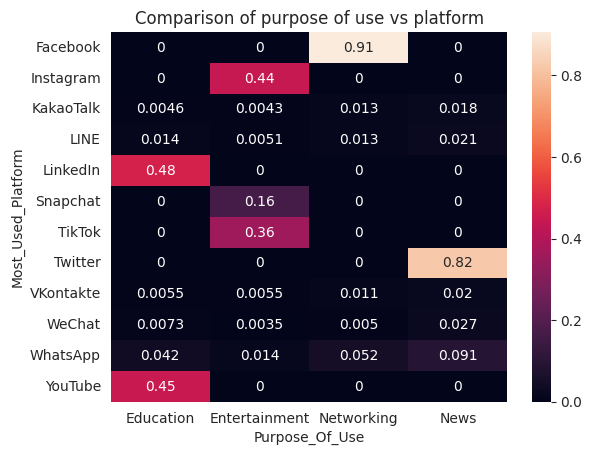

In [218]:
plt.title('Comparison of purpose of use vs platform')
sns.heatmap(platform_vs_purpose,annot=True)

- Among the students who use social media for **networking**, **91%** use **Facebook**, making it the most preferred platform for networking.

- Among the students who use social media for **entertainment**, **44%** use **Instagram**, **36%** use **TikTok**, and **16%** use **Snapchat**, making these the top three platforms used for entertainment.

- Among the students who use social media to **follow news and current events**, **82%** use **Twitter**, indicating that it is the dominant platform for news consumption.

- Among the students who use social media for **educational purposes**, **48%** use **LinkedIn**, while **45%** use **YouTube**, making them the two most preferred platforms for educational and professional learning.

- The remaining social media platforms are used by only a small proportion of students. Many of these platforms serve **multiple purposes**, while some are primarily used by students from specific countries due to regional popularity and availability.

In [219]:
academic_level_vs_purpose_of_use=pd.crosstab(df2['Academic_Level'],df2['Purpose_Of_Use'],normalize='index')*100
academic_level_vs_purpose_of_use

Purpose_Of_Use,Education,Entertainment,Networking,News
Academic_Level,,,,
Graduate,28.322440,45.751634,13.180828,12.745098
High School,29.777778,41.111111,11.333333,17.777778
Undergraduate,19.273128,53.606828,17.098018,10.022026


<Axes: title={'center': 'Comparison between academic level vs purpose of use'}, xlabel='Purpose_Of_Use', ylabel='Academic_Level'>

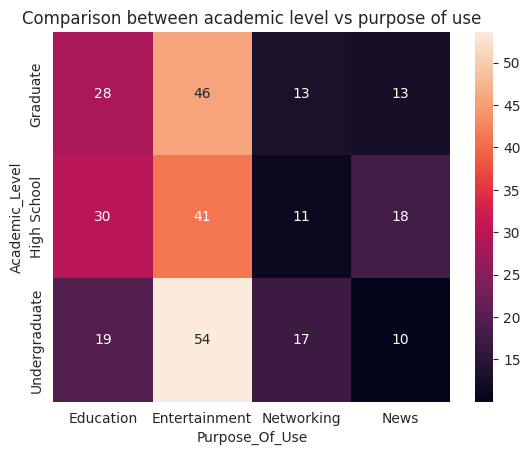

In [220]:
plt.title('Comparison between academic level vs purpose of use')
sns.heatmap(academic_level_vs_purpose_of_use,annot=True)

After analyzing the relationship between **academic level** and the **primary purpose of social media use**, the following observations were made:

- Around **17%** of **undergraduate students** use social media primarily for **networking**, which is higher than **graduate students (13%)** and **high school students (11%)**.

- **Entertainment** is the most common primary purpose of social media use across all academic levels. Approximately **54%** of undergraduate students use social media mainly for entertainment, making it the largest user group. A similar trend is observed among graduate and high school students.

- Among **high school students**, **30%** primarily use social media for **educational purposes**, representing the highest proportion compared to the other academic levels.

- Across all three academic levels—**high school, undergraduate, and graduate**—social media is used comparatively less for **news consumption** and **networking** than for entertainment and educational purposes.

In [221]:
stress_level_vs_academic_level=pd.crosstab(df2['Academic_Level'],df2['Stress_Level'],normalize='index')*100
stress_level_vs_academic_level

Stress_Level,High,Low,Medium,Very High
Academic_Level,,,,
Graduate,22.984749,16.775599,26.470588,33.769063
High School,23.777778,11.333333,16.888889,48.000000
Undergraduate,30.892070,12.087004,26.872247,30.148678


<Axes: title={'center': 'Comparison between academic level vs Stress'}, xlabel='Stress_Level', ylabel='Academic_Level'>

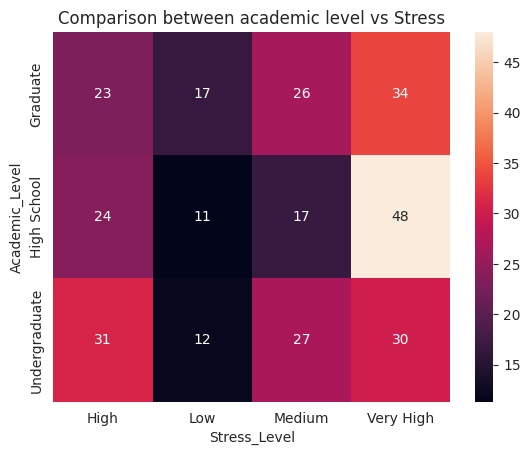

In [222]:
plt.title('Comparison between academic level vs Stress')
sns.heatmap(stress_level_vs_academic_level,annot=True)

After analyzing the relationship between **Academic Level** and **Stress Level**, the following observations were made:

- **Very High** stress is the most common stress level among **Graduate (33.77%)** and **High School (48.00%)** students, indicating that a considerable proportion of students in these academic levels experience very high stress.

- Among **Undergraduate** students, **High stress (30.89%)** is the most prevalent, followed closely by **Very High stress (30.15%)**, suggesting that a majority of undergraduate students experience elevated stress levels.

- **Medium stress** accounts for approximately **26–27%** of both undergraduate and graduate students, whereas only **16.89%** of high school students fall into this category.

- **Low stress** is the least common category across all academic levels, accounting for only **11–17%** of students, indicating that relatively few students report low stress.

- Overall, the findings suggest that **high and very high stress levels dominate across all academic levels**, with **high school students exhibiting the highest proportion of very high stress (48%)**, followed by graduates (33.77%) and undergraduates (30.15%).

<Axes: title={'center': 'Comparison of average daily social media usage hours between different academic level'}, xlabel='Avg_Daily_Usage_Hours', ylabel='Density'>

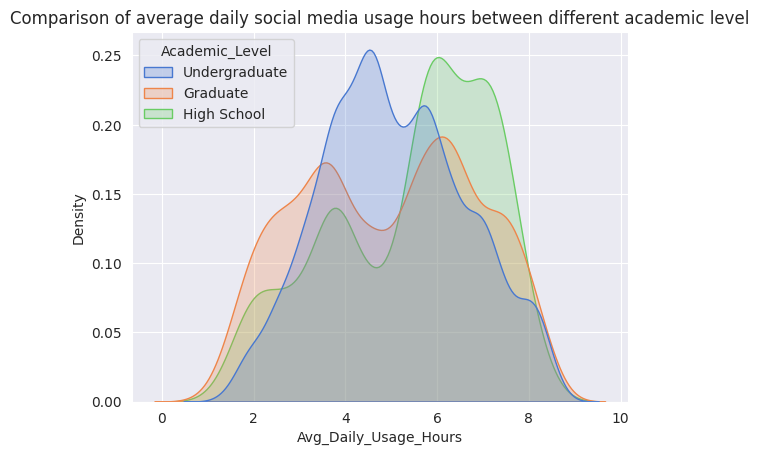

In [223]:
plt.title('Comparison of average daily social media usage hours between different academic level')
sns.kdeplot(
    data=df2,
    x="Avg_Daily_Usage_Hours",
    hue="Academic_Level",
    fill=True,
    common_norm=False,
    bw_adjust=0.8
)

High School students are the largest heavy-user group, with most concentrated between 6–8 hours/day. Their distribution is left-skewed, showing that the majority spend significant time on social media with fewer light users.

Undergraduates are more balanced, with the main peak around 4–5 hours/day (moderate users), but also a secondary peak at 6 hours/day. This indicates a split: most are moderate users, but a notable subgroup mirrors high school–level heavy usage.

Graduates show the widest spread. While there is a peak around 3–4 hours/day (moderate/light users), the second peak at 6 hours/day is stronger, meaning heavy users actually dominate among graduates.

In [224]:
correlation_data=df2.corr(numeric_only=True)

Text(0.5, 1.0, 'Correlation matrix of the numerical columns')

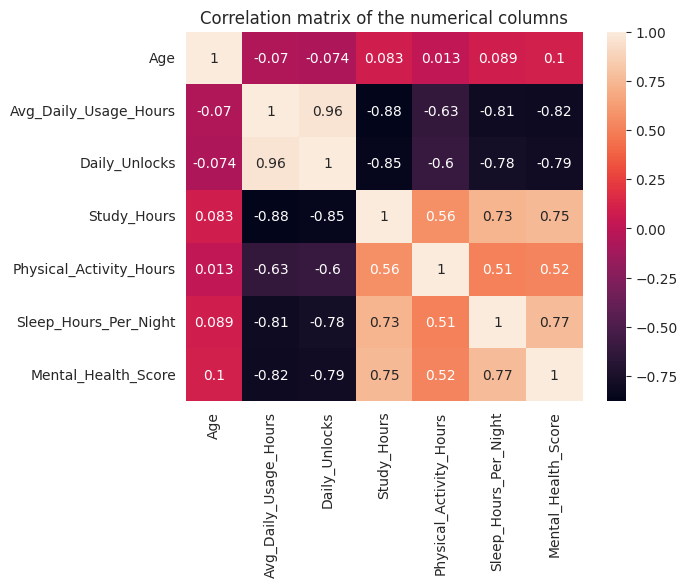

In [225]:
sns.heatmap(correlation_data,annot=True)
plt.title('Correlation matrix of the numerical columns')

As daily social media usage increases, study hours tend to decrease. The correlation matrix indicates a strong negative correlation of -0.88 between daily social media usage hours and study hours, suggesting that students who spend more time on social media generally study fewer hours.

Similarly, the correlation matrix shows a moderate negative correlation of -0.63 between daily social media usage and physical activity hours. This indicates that higher social media usage is also associated with lower levels of physical activity among students.

<Axes: title={'center': 'Comparison between social media usage time vs Mental health score'}, xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

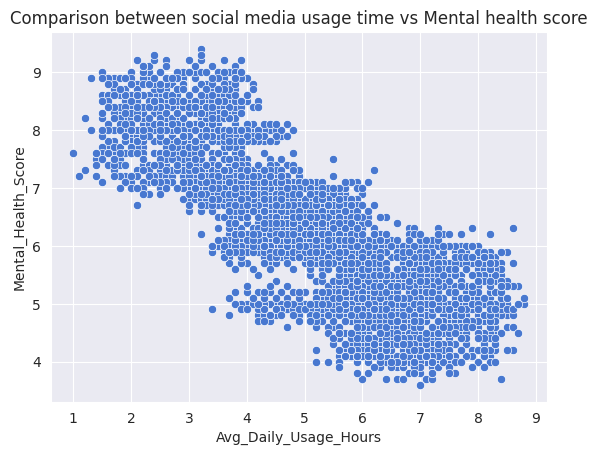

In [226]:
plt.title('Comparison between social media usage time vs Mental health score')
sns.scatterplot(x=df2['Avg_Daily_Usage_Hours'],y=df2['Mental_Health_Score'])

After analyzing the correlation matrix, it was found that the average daily social media usage hours are strongly negatively correlated with the mental health score, with a correlation coefficient of -0.82. This indicates that as students spend more time on social media, their mental health scores tend to decrease. In other words, higher social media usage is associated with poorer mental health among the students. However, it is important to note that correlation does not imply causation; this relationship indicates an association rather than proving that increased social media usage directly causes poorer mental health.

<Axes: xlabel='Physical_Activity_Hours', ylabel='Density'>

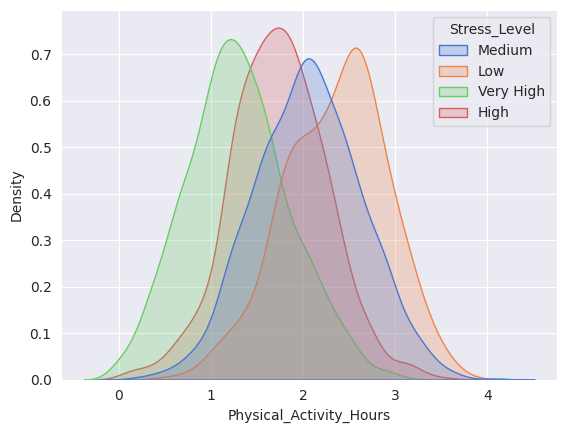

In [227]:
sns.kdeplot(x=df2['Physical_Activity_Hours'],common_norm=False,hue=df2['Stress_Level'],fill=True)

The comparison between daily physical activity hours and stress level indicates that increased physical activity is generally associated with better stress management. Students experiencing high stress show a peak around 1 hour of physical activity per day, while those with medium stress peak around 2 hours, and students with low stress show the highest peak at approximately 3 hours per day. This pattern suggests that students who engage in more physical activity tend to experience lower stress levels. However, the distribution also reveals that some students who exercise for 3–4 hours per day still report high stress levels, indicating that although physical activity may contribute to stress reduction, it is not the only factor influencing stress.

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Density'>

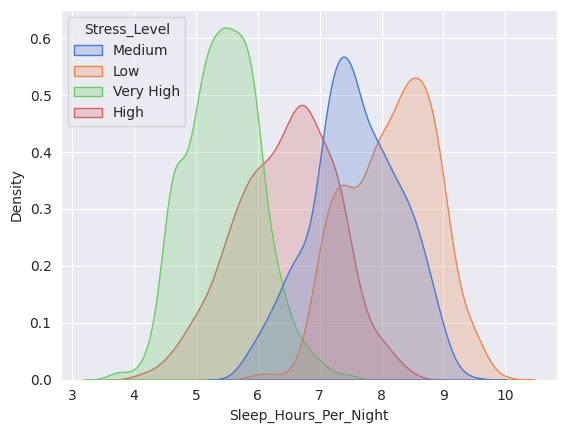

In [228]:
sns.kdeplot(x=df2['Sleep_Hours_Per_Night'],common_norm=False,hue=df2['Stress_Level'],fill=True)



> The comparison between **daily sleep hours** and **stress levels** indicates that students experiencing **very high stress** generally sleep less than other students, with a peak around **5–5.5 hours** of sleep per night. Students with **high stress** typically have a peak between **6 and 7 hours**, those with **medium stress** peak around **7–8 hours**, while students experiencing **low stress** generally sleep for **more than 8 hours** per night. This pattern suggests that longer sleep duration is associated with lower stress levels. However, the distribution also shows that some students who sleep **more than 7 hours** still experience high levels of stress. This indicates that although adequate sleep may contribute to better stress management, it is not the only factor influencing stress levels, and other variables may also play a significant role.


<Axes: title={'center': 'Stress level comparsion based on study hours'}, xlabel='Study_Hours', ylabel='Density'>

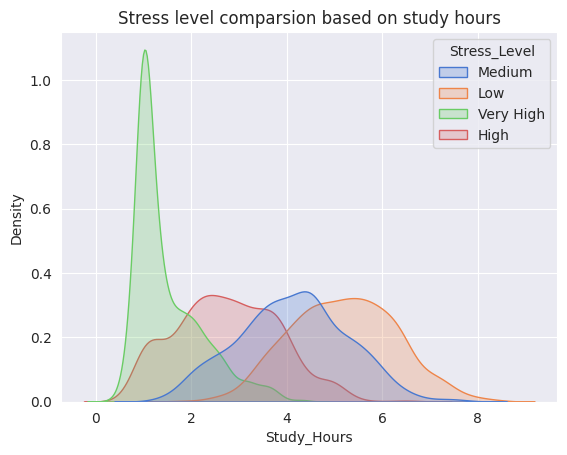

In [229]:
plt.title('Stress level comparsion based on study hours')
sns.kdeplot(x=df2['Study_Hours'],common_norm=False,hue=df2['Stress_Level'],fill=True)



> The comparison between **daily study hours** and **stress levels** shows that students experiencing **high stress** generally study for **less than 4 hours per day**, with a sharp peak around **1 hour**. As study hours increase, the proportion of students experiencing higher stress levels appears to decrease, suggesting that students who study for longer durations tend to report lower stress levels. This observation is further supported by the correlation matrix, which shows a **strong positive correlation (r = 0.75)** between **study hours** and **mental health score**. This indicates that students who spend more time studying tend to have higher mental health scores, which are associated with lower stress levels. However, this relationship represents an **association rather than causation**, meaning that increased study hours alone cannot be concluded to directly improve mental health or reduce stress, as other factors may also influence these outcomes.


In [230]:
gender_vs_stress_level=pd.crosstab(df2['Gender'],df2['Stress_Level'],normalize='index')
gender_vs_stress_level

Stress_Level,High,Low,Medium,Very High
Gender,,,,
Female,0.304440,0.127273,0.238478,0.329810
Male,0.273245,0.130171,0.277419,0.319165


<Axes: xlabel='Stress_Level', ylabel='Gender'>

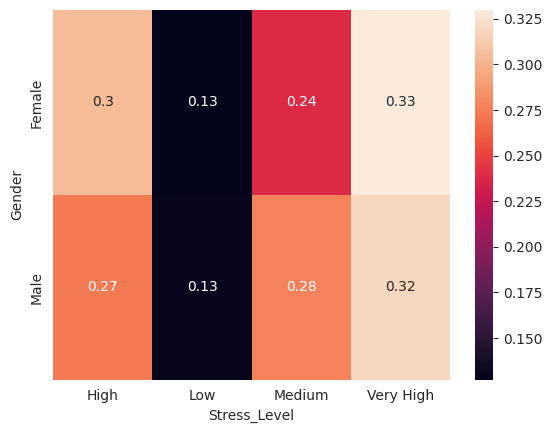

In [231]:
sns.heatmap(gender_vs_stress_level,annot=True)

<Axes: title={'center': 'Comparison of social media usage purpose of use vs Stress levels'}, xlabel='Stress_Level', ylabel='Purpose_Of_Use'>

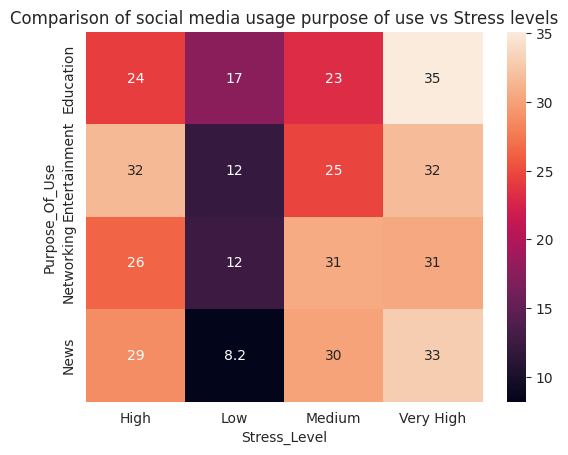

In [232]:
plt.title('Comparison of social media usage purpose of use vs Stress levels')
sns.heatmap(pd.crosstab(df2['Purpose_Of_Use'],df2['Stress_Level'],normalize='index')*100,annot=True)

Among students who primarily use social media for education, 35% reported high stress levels, which is the highest proportion compared to students using social media for entertainment, networking, or news. However, the education category also has the highest proportion of students reporting low stress levels (17%), whereas the corresponding percentages for the other categories range from 8% to 12%.

Similarly, among students who primarily use social media for entertainment, 32% reported very high stress levels. Overall, while the education category has the largest share of students experiencing high stress, it also has the highest share of students reporting low stress, suggesting that the relationship between the purpose of social media use and stress levels is not straightforward and may be influenced by other factors.



### Key Findings

1. **Social media platform preference depends on the purpose of use.**

   * Facebook is predominantly used for networking (91%).
   * Instagram (44%) and TikTok (36%) are the most popular platforms for entertainment.
   * Twitter is the dominant platform for news consumption (82%).
   * LinkedIn (48%) and YouTube (45%) are the preferred platforms for educational purposes.

2. **Entertainment is the primary reason for social media use across all academic levels**, while networking and news consumption are the least common purposes.

3. **High school students are the heaviest social media users**, with most spending 6–8 hours per day on social media. Undergraduate students show a balanced usage pattern, while graduate students exhibit the widest variation in usage.

4. **High and very high stress levels dominate across all academic levels.**

   * High school students report the highest proportion of very high stress (48%).
   * Undergraduate and graduate students also experience predominantly high stress levels.

5. **Daily social media usage is strongly negatively correlated with study hours (r = -0.88).**

   * Students who spend more time on social media generally study fewer hours.

6. **Daily social media usage is strongly negatively correlated with mental health score (r = -0.82).**

   * Higher social media usage is associated with lower mental health scores.

7. **Daily social media usage is moderately negatively correlated with physical activity (r = -0.63).**

   * Students with higher social media usage generally engage in less physical activity.

8. **Study hours are strongly positively correlated with mental health score (r = 0.75).**

   * Students who study for longer durations tend to have better mental health scores and lower stress levels.

9. **Students with higher physical activity generally report lower stress levels.**

   * Stress tends to decrease as daily physical activity increases, although physical activity alone does not determine stress.

10. **Students who sleep longer generally experience lower stress levels.**

    * Very high stress is most common among students sleeping around 5–5.5 hours, whereas low stress is more common among students sleeping more than 8 hours.

11. **The relationship between the purpose of social media use and stress is mixed.**

    * Students using social media primarily for education have both the highest proportion of high stress (35%) and the highest proportion of low stress (17%), suggesting that purpose alone does not determine stress levels.

12. **Overall, lifestyle factors—including study hours, sleep duration, and physical activity—show stronger associations with mental health than the primary purpose of social media use.**

> **Note:** All of these findings describe **associations observed in the data** and should not be interpreted as evidence of **cause-and-effect relationships**.


## Final Conclusion

The exploratory data analysis (EDA) provides valuable insights into students' social media usage patterns, academic behavior, lifestyle habits, and mental health. The analysis revealed that students use different social media platforms for different purposes. Facebook was the most preferred platform for networking, Instagram and TikTok dominated entertainment, Twitter was primarily used for news consumption, while LinkedIn and YouTube were the most preferred platforms for educational purposes.

Across all academic levels, entertainment emerged as the primary purpose of social media use, whereas networking and news consumption were comparatively less common. High school students showed the highest proportion of educational use, while undergraduate students were more likely to use social media for networking. Social media usage patterns also varied by academic level, with high school students exhibiting the highest concentration of heavy users, undergraduate students showing a balanced distribution of moderate and heavy users, and graduate students displaying the widest variation in daily usage.

The analysis further indicated that high and very high stress levels were prevalent across all academic levels. High school students reported the highest proportion of very high stress, followed by graduate and undergraduate students, while low stress levels were observed in only a small percentage of students. The relationship between the primary purpose of social media use and stress levels was less conclusive. Although students using social media mainly for educational purposes showed the highest proportion of high stress, they also had the highest proportion of low stress, suggesting that the purpose of social media use alone is insufficient to explain differences in stress levels.

Correlation analysis identified several strong associations among the variables. Daily social media usage showed a strong negative correlation with study hours and mental health scores, indicating that students who spent more time on social media generally studied less and tended to have lower mental health scores. A moderate negative correlation was also observed between social media usage and physical activity, suggesting that increased social media use is associated with reduced physical exercise.

Lifestyle habits were also found to be associated with students' mental well-being. Students who engaged in greater physical activity, obtained adequate sleep, and spent more time studying generally reported lower stress levels and higher mental health scores. However, the distributions also showed that some students with healthy lifestyle habits still experienced high stress, indicating that mental health is influenced by multiple factors beyond social media usage, sleep, physical activity, and study habits.

Overall, the EDA demonstrates meaningful relationships between students' social media behavior, lifestyle factors, and mental health. These findings provide a strong foundation for further statistical analysis and predictive modeling to better understand the factors associated with students' well-being. However, since the analysis is exploratory and primarily based on correlations, the observed relationships should be interpreted as associations rather than evidence of cause-and-effect relationships.
